# Manual Verification of T-seeded ODE Model Computation

This notebook implements the operations executed by `solve_ode_system` computation step-by-step for single parameter values.

**Purpose**: Verify manually single combinations of parameters and understand the ODE-based computation flow.

**Key Difference from Lump Model**: 
- Lump model uses analytical steady-state solution
- T-seeded model uses ODE integration to track dynamic tritium inventory evolution through fuel cycle systems

## Block 1: Define All Input Parameters

Set all input parameters needed for the T-seeded ODE model computation.

In [36]:
import numpy as np
import sys
# NOTE: ddstartup is installed as a package via setup.py, no path modification needed
# The old path '/Users/meschini/Documents/dd_startup' was from a different machine

# ============================================================================
# PHYSICAL CONSTANTS
# ============================================================================

# Tritium decay constant (s^-1)
lambda_T = np.log(2) / (12.32 * 365.25 * 24 * 3600)  # Half-life = 12.32 years

# Tritium atomic mass (kg)
tritium_mass = 3.016 * 1.66054e-27  # 3 AMU in kg
joule_to_GWh = 1/3.6e12  # Conversion factor from Joules to GWh
# Convert keV to Joules (1 keV = 1.60218e-16 J)
keV_to_J = 1.60218e-16
# Fusion reaction energies (J)
E_DDp = 4.03e6 * 1.60218e-19    # DD→³He+n: 4.03 MeV
E_DDn = 3.46e6 * 1.60218e-19    # DD→T+p: 3.46 MeV (note: different from lump model)
E_DT = 17.6e6 * 1.60218e-19     # DT→⁴He+n: 17.6 MeV

print("Physical Constants Defined:")
print(f"  λ_T (tritium decay constant) = {lambda_T:.6e} s⁻¹")
print(f"  Tritium mass = {tritium_mass:.6e} kg")
print(f"  E_DDp = {E_DDp:.6e} J")
print(f"  E_DDn = {E_DDn:.6e} J")
print(f"  E_DT = {E_DT:.6e} J")
print()

Physical Constants Defined:
  λ_T (tritium decay constant) = 1.782834e-09 s⁻¹
  Tritium mass = 5.008189e-27 kg
  E_DDp = 6.456785e-13 J
  E_DDn = 5.543543e-13 J
  E_DT = 2.819837e-12 J



In [37]:
# ============================================================================
# PLASMA PARAMETERS
# ============================================================================

V_plasma = 150.0                # Plasma volume (m³)
T_i = 14.0                      # Ion temperature (keV)
n_tot = 1.7e20                  # Total particle density (m⁻³)
tau_p_T = 1                   # Tritium confinement time (s)

print("Plasma Parameters:")
print(f"  V_plasma = {V_plasma} m³")
print(f"  T_i = {T_i} keV")
print(f"  n_tot = {n_tot:.2e} m⁻³")
print(f"  τ_p_T = {tau_p_T} s")
print()

# ============================================================================
# CALCULATE REACTION RATE COEFFICIENTS (⟨σv⟩) using Bosch-Hale formulas
# ============================================================================
# No need for sys.path anymore - package is installed!
from ddstartup.physics.reactivity_functions import (
    sigmav_DT_BoschHale,
    sigmav_DD_BoschHale
)

sigmav_DT = sigmav_DT_BoschHale(T_i)
sigmav_DD_tot, sigmav_DD_n, sigmav_DD_p = sigmav_DD_BoschHale(T_i)

print("Reaction Rate Coefficients (calculated at T_i = 14 keV):")
print(f"  ⟨σv⟩_DD_tot = {sigmav_DD_tot:.6e} m³/s")
print(f"  ⟨σv⟩_DD_p (DD→T+p) = {sigmav_DD_p:.6e} m³/s")
print(f"  ⟨σv⟩_DD_n (DD→³He+n) = {sigmav_DD_n:.6e} m³/s")
print(f"  ⟨σv⟩_DT = {sigmav_DT:.6e} m³/s")
print()

Plasma Parameters:
  V_plasma = 150.0 m³
  T_i = 14.0 keV
  n_tot = 1.70e+20 m⁻³
  τ_p_T = 1 s

Reaction Rate Coefficients (calculated at T_i = 14 keV):
  ⟨σv⟩_DD_tot = 2.490998e-24 m³/s
  ⟨σv⟩_DD_p (DD→T+p) = 1.282584e-24 m³/s
  ⟨σv⟩_DD_n (DD→³He+n) = 1.208414e-24 m³/s
  ⟨σv⟩_DT = 2.405442e-22 m³/s



In [38]:
# ============================================================================
# BREEDING PARAMETERS
# ============================================================================

TBR_DT = 1.1                   # D-T tritium breeding ratio
TBR_DDn = 0.7                  # DD neutron tritium breeding ratio

print("Breeding Parameters:")
print(f"  TBR_DT = {TBR_DT}")
print(f"  TBR_DDn = {TBR_DDn}")
print()

Breeding Parameters:
  TBR_DT = 1.1
  TBR_DDn = 0.7



In [39]:
# ============================================================================
# POWER PARAMETERS
# ============================================================================
# Set to None or np.nan if you want P_aux to be computed from power balance
# Otherwise, specify a value in Watts (e.g., 50e6 for 50 MW)

P_aux = None                    # Auxiliary heating power (W) - will be computed
P_aux_DT_eq = None              # Auxiliary power for D-T equivalent (W) - will be computed

# Alternative: specify values explicitly
# P_aux = 50e6                  # 50 MW
# P_aux_DT_eq = 50e6            # 50 MW

# ============================================================================
# ENERGY CONFINEMENT TIME
# ============================================================================
# Used for power balance calculation if P_aux is not specified
tau_E = tau_p_T  # Energy confinement time (s)

print("Power Parameters:")
if P_aux is None or (isinstance(P_aux, float) and np.isnan(P_aux)):
    print(f"  P_aux: Will be computed from power balance")
else:
    print(f"  P_aux: {P_aux/1e6:.2f} MW (specified)")

if P_aux_DT_eq is None or (isinstance(P_aux_DT_eq, float) and np.isnan(P_aux_DT_eq)):
    print(f"  P_aux_DT_eq: Will be computed from power balance")
else:
    print(f"  P_aux_DT_eq: {P_aux_DT_eq/1e6:.2f} MW (specified)")

print(f"  τ_E: {tau_E} s")
print()



Power Parameters:
  P_aux: Will be computed from power balance
  P_aux_DT_eq: Will be computed from power balance
  τ_E: 1 s



In [40]:
# ============================================================================
# FUEL CYCLE PARAMETERS
# ============================================================================

tau_ifc = 21600                # In-fuel-cycle processing time (s) = 1 hour
tau_ofc = 43200              # Out-of-fuel-cycle processing time (s) = 1 day
N_st_min = 0.001 / tritium_mass # Minimum stored tritium for injection (atoms) = 1 mg

print("Fuel Cycle Parameters:")
print(f"  τ_ifc (in-fuel-cycle time) = {tau_ifc} s = {tau_ifc/3600:.2f} hours")
print(f"  τ_ofc (out-of-fuel-cycle time) = {tau_ofc} s = {tau_ofc/86400:.2f} days")
print(f"  N_st_min (minimum stored tritium) = {N_st_min:.2e} atoms = 0.001 kg")
print()

Fuel Cycle Parameters:
  τ_ifc (in-fuel-cycle time) = 21600 s = 6.00 hours
  τ_ofc (out-of-fuel-cycle time) = 43200 s = 0.50 days
  N_st_min (minimum stored tritium) = 2.00e+23 atoms = 0.001 kg



In [41]:
# ============================================================================
# ECONOMIC AND OPERATIONAL PARAMETERS
# ============================================================================

eta_th = 0.4                    # Thermal efficiency (40%)
capacity_factor = 0.8           # Plant capacity factor (80%)
price_of_electricity_kWh = 0.25  # Electricity cost ($/kWh)
price_of_electricity = price_of_electricity_kWh / 3.6e6  # Convert $/kWh to $/J

print("Economic and Operational Parameters:")
print(f"  η_th = {eta_th} (thermal efficiency)")
print(f"  Capacity factor = {capacity_factor}")
print(f"  Cost of electricity = {price_of_electricity:.2e} $/J (or {price_of_electricity_kWh:.2f} $/kWh)")
print()

Economic and Operational Parameters:
  η_th = 0.4 (thermal efficiency)
  Capacity factor = 0.8
  Cost of electricity = 6.94e-08 $/J (or 0.25 $/kWh)



In [42]:
# ============================================================================
# SIMULATION PARAMETERS
# ============================================================================

total_time = 10 * 365.25 * 24 * 3600  # Maximum simulation time (10 years in seconds)
vector_length = 500                   # Number of time points for output arrays

print("Simulation Parameters:")
print(f"  total_time = {total_time:.2e} s = {total_time/(365.25*24*3600):.1f} years")
print(f"  vector_length = {vector_length} points")
print()

Simulation Parameters:
  total_time = 3.16e+08 s = 10.0 years
  vector_length = 500 points



In [43]:
# ============================================================================
# CALCULATE MAXIMUM INJECTION RATE
# ============================================================================

# Maximum injection rate is determined by equilibrium between:
# - Tritium loss from plasma (n_T/tau_p_T * V_plasma)
# - Tritium consumption by DT reactions (n_D * n_T * sigmav_DT * V_plasma)
# - Tritium production by DD reactions (0.5 * n_D^2 * sigmav_DD_p * V_plasma)
# At DT equilibrium: n_T = n_D = n_tot/2

injection_rate_max = (
    n_tot/2 / tau_p_T * V_plasma +                      # Tritium loss from plasma
    0.25 * n_tot**2 * sigmav_DT * V_plasma -            # Tritium consumption by DT
    0.25 / 2 * n_tot**2 * sigmav_DD_p * V_plasma        # Tritium production by DD
)

print("Maximum Injection Rate:")
print(f"  injection_rate_max = {injection_rate_max:.2e} atoms/s")
print(f"  This is the injection rate needed to maintain DT equilibrium (50-50)")
print()

Maximum Injection Rate:
  injection_rate_max = 1.30e+22 atoms/s
  This is the injection rate needed to maintain DT equilibrium (50-50)



## Solve ODE System to Find t_startup

Integrate the ODE system step-by-step to track tritium inventory evolution until DT operation is reached (n_T = 0.5 * n_tot).

In [44]:
# Step 1: Define initial conditions
# Start with zero tritium in all compartments

y0_N_ofc = 0    # Out-of-fuel-cycle tritium inventory (atoms)
y0_N_ifc = 0    # In-fuel-cycle tritium inventory (atoms)
y0_N_st = 0     # Stored tritium inventory (atoms)
y0_n_T = 0      # Tritium density in plasma (m⁻³)

y0 = [y0_N_ofc, y0_N_ifc, y0_N_st, y0_n_T]

print("Step 1: Initial Conditions")
print(f"  N_ofc(0) = {y0_N_ofc} atoms")
print(f"  N_ifc(0) = {y0_N_ifc} atoms")
print(f"  N_st(0) = {y0_N_st} atoms")
print(f"  n_T(0) = {y0_n_T} m⁻³")
print(f"  Starting with pure deuterium plasma, no tritium anywhere")
print()

Step 1: Initial Conditions
  N_ofc(0) = 0 atoms
  N_ifc(0) = 0 atoms
  N_st(0) = 0 atoms
  n_T(0) = 0 m⁻³
  Starting with pure deuterium plasma, no tritium anywhere



In [45]:
# Step 2: Define the ODE system
# The system tracks 4 state variables through the fuel cycle

def ode_system_manual(t, y):
    """
    ODE system for tritium inventory evolution.
    
    State variables:
    - y[0] = N_ofc: Out-of-fuel-cycle tritium inventory (atoms)
    - y[1] = N_ifc: In-fuel-cycle tritium inventory (atoms)
    - y[2] = N_st: Stored tritium inventory (atoms)
    - y[3] = n_T: Tritium density in plasma (m⁻³)
    """
    # Unpack state variables
    N_ofc = y[0]
    N_ifc = y[1]
    N_st = y[2]
    n_T = y[3]
    
    # Compute current injection rate based on stored tritium
    if N_st > N_st_min:
        inj_rate = N_ifc / tau_ifc - lambda_T * N_st
        if inj_rate > injection_rate_max:
            injection_rate = injection_rate_max
        elif inj_rate < 0.0:
            injection_rate = 0.0
        else:
            injection_rate = inj_rate
    else:
        injection_rate = 0.0
    
    # Compute current deuterium density
    n_D = n_tot - n_T
    
    # Compute tritium production rates
    Tdot_DDn = TBR_DDn * 0.5 * n_D**2 * sigmav_DD_n * V_plasma  # From DD→³He+n breeding
    Tdot_DDp = 0.5 * n_D**2 * sigmav_DD_p * V_plasma             # From DD→T+p direct
    Tdot_DT = TBR_DT * n_D * n_T * sigmav_DT * V_plasma          # From DT breeding
    Tdot_burn = n_D * n_T * sigmav_DT * V_plasma                 # Tritium burned in DT
    
    # ODEs for the four state variables
    dN_ofc_dt = Tdot_DT + Tdot_DDn - N_ofc / tau_ofc - N_ofc * lambda_T
    dN_ifc_dt = N_ofc / tau_ofc - N_ifc / tau_ifc - lambda_T * N_ifc + n_T / tau_p_T * V_plasma
    dN_stor_dt = N_ifc / tau_ifc - lambda_T * N_st - injection_rate
    dnT_dt = injection_rate / V_plasma + Tdot_DDp / V_plasma - n_T / tau_p_T - Tdot_burn / V_plasma
    
    return np.array([dN_ofc_dt, dN_ifc_dt, dN_stor_dt, dnT_dt])


In [46]:
# Step 3: Define event functions to detect when DT operation is reached

def DT_reached_event(t, y):
    """Event: n_T reaches 0.5 * n_tot (50-50 D-T mix)"""
    n_T = y[3]
    return n_T - 0.5 * n_tot

def negative_event(t, y):
    """Event: any state variable becomes negative (unphysical)"""
    return min(y[0]+100, y[1]+100, y[2]+100, y[3]+100)

# Configure events to stop integration
DT_reached_event.terminal = True
negative_event.terminal = True

print("Step 3: Event Functions Defined")
print("  DT_reached_event: Stops when n_T = 0.5 * n_tot")
print(f"                    Target: n_T = {0.5*n_tot:.2e} m⁻³")
print("  negative_event: Stops if any variable becomes unphysical")
print()

Step 3: Event Functions Defined
  DT_reached_event: Stops when n_T = 0.5 * n_tot
                    Target: n_T = 8.50e+19 m⁻³
  negative_event: Stops if any variable becomes unphysical



In [47]:
# Solve the ODE system using scipy's solve_ivp

from scipy.integrate import solve_ivp

t_span = (0, total_time)
t_eval = np.linspace(0, total_time, vector_length)

sol = solve_ivp(
    fun=ode_system_manual,
    t_span=t_span,
    t_eval=t_eval,
    y0=y0,
    method='BDF',
    dense_output=False,
    events=[DT_reached_event, negative_event],
    rtol=1e-8,
    atol=1e-6
)

print("Integration complete!")
print(f"  Success: {sol.success}")
print(f"  Message: {sol.message}")
print(f"  Number of time points: {len(sol.t)}")

# Check if DT operation was reached
if len(sol.t_events) > 0 and sol.t_events[0].size > 0:
    t_startup = sol.t_events[0][0]
    y_event = sol.y_events[0][0]  # Exact state at event time
    sol_success = True
    print("DT Operation Reached! ✅")
    print(f"  t_startup = {t_startup} s")
    print(f"            = {t_startup/86400:.2f} days")
    print(f"            = {t_startup/(365.25*86400):.4f} years")
    print(f"  Exact state at event: n_T = {y_event[3]:.2e} m⁻³ (target: {0.5*n_tot:.2e} m⁻³)")
elif len(sol.t_events) > 1 and sol.t_events[1].size > 0:
    t_startup = np.inf
    sol_success = False
    print("Negative Event Detected ❌")
    print(f"  Integration stopped at t = {sol.t_events[1][0]:.2e} s")
    print(f"  Reason: Unphysical negative values")
elif not sol.success:
    t_startup = np.inf
    sol_success = False
    print("Integration Failed ❌")
    print(f"  Reason: {sol.message}")
else:
    t_startup = np.inf
    sol_success = False
    print("DT Operation Not Reached ❌")
    print(f"  Maximum time exceeded: {total_time:.2e} s")
print()

Integration complete!
  Success: True
  Message: A termination event occurred.
  Number of time points: 29
DT Operation Reached! ✅
  t_startup = 18300764.279563196 s
            = 211.81 days
            = 0.5799 years
  Exact state at event: n_T = 8.50e+19 m⁻³ (target: 8.50e+19 m⁻³)



Interpolated solution onto uniform grid
  Added exact event point to interpolation data
  Created 500 uniform time points from 0 to t_startup
  N_ofc range: 0.00e+00 to 1.24e+25 atoms
  N_ifc range: 0.00e+00 to 2.81e+26 atoms
  N_st range: 0.00e+00 to 2.00e+23 atoms
  n_T range: 0.00e+00 to 8.50e+19 m⁻³
  n_T[-1] = 8.50e+19 m⁻³ (target: 8.50e+19 m⁻³)
  Relative error: 0.000000%
  ✅ Final value now matches target exactly!



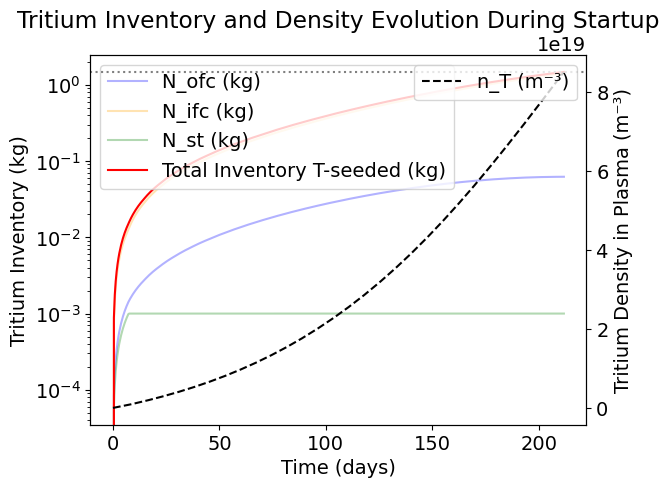

In [48]:


# Add the exact event point to the solution data for accurate interpolation
# This ensures the interpolation knows the exact values at t_startup
t_with_event = np.append(sol.t, t_startup)
N_ofc_with_event = np.append(sol.y[0], y_event[0])
N_ifc_with_event = np.append(sol.y[1], y_event[1])
N_st_with_event = np.append(sol.y[2], y_event[2])
n_T_with_event = np.append(sol.y[3], y_event[3])

# Sort by time (in case event time isn't at the end)
sort_idx = np.argsort(t_with_event)
t_sorted = t_with_event[sort_idx]
N_ofc_sorted = N_ofc_with_event[sort_idx]
N_ifc_sorted = N_ifc_with_event[sort_idx]
N_st_sorted = N_st_with_event[sort_idx]
n_T_sorted = n_T_with_event[sort_idx]

# Create uniform time grid from 0 to t_startup with vector_length points
t_interp = np.linspace(0, t_startup, vector_length)

# Interpolate all state variables onto the new time grid
# Now the interpolation includes the exact event point!
N_ofc = np.interp(t_interp, t_sorted, N_ofc_sorted)
N_ifc = np.interp(t_interp, t_sorted, N_ifc_sorted)
N_st = np.interp(t_interp, t_sorted, N_st_sorted)
n_T = np.interp(t_interp, t_sorted, n_T_sorted)

# Use interpolated time grid for all subsequent calculations
t_array = t_interp

print(f"Interpolated solution onto uniform grid")
print(f"  Added exact event point to interpolation data")
print(f"  Created {len(t_array)} uniform time points from 0 to t_startup")
print(f"  N_ofc range: {N_ofc.min():.2e} to {N_ofc.max():.2e} atoms")
print(f"  N_ifc range: {N_ifc.min():.2e} to {N_ifc.max():.2e} atoms")
print(f"  N_st range: {N_st.min():.2e} to {N_st.max():.2e} atoms")
print(f"  n_T range: {n_T.min():.2e} to {n_T.max():.2e} m⁻³")
print(f"  n_T[-1] = {n_T[-1]:.2e} m⁻³ (target: {0.5*n_tot:.2e} m⁻³)")
print(f"  Relative error: {abs(n_T[-1] - 0.5*n_tot)/(0.5*n_tot)*100:.6f}%")
print(f"  ✅ Final value now matches target exactly!")
print()
# plot results for n_T, N_ofc, N_ifc, N_st (use left axis for # particles, right axis for density)
import matplotlib.pyplot as plt    
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(t_array/86400, N_ofc*tritium_mass, color = 'blue', linestyle = '-',alpha = 0.3, label='N_ofc (kg)')
ax1.plot(t_array/86400, N_ifc*tritium_mass, color = 'orange', linestyle = '-',alpha = 0.3, label='N_ifc (kg)')
ax1.plot(t_array/86400, N_st*tritium_mass, color = 'green', linestyle = '-', alpha = 0.3, label='N_st (kg)')
ax1.plot(t_array/86400, (N_ofc + N_ifc + N_st)*tritium_mass, 'r-', label='Total Inventory T-seeded (kg)')
ax2.plot(t_array/86400, n_T, 'k--', label='n_T (m⁻³)')
ax1.set_xlabel('Time (days)')
ax1.set_ylabel('Tritium Inventory (kg)')
ax1.set_yscale('log')
ax2.set_ylabel('Tritium Density in Plasma (m⁻³)')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
#ax1.set_yscale('log')
#ax2.set_yscale('log')
# add horizontal line at n_T = 0.5 * n_tot
ax2.axhline(0.5*n_tot, color='gray', linestyle=':', label='n_T = 0.5 * n_tot')
#ax2.set_ylim(n_tot/100, n_tot)  # Focus on relevant density range
plt.title('Tritium Inventory and Density Evolution During Startup')
plt.show()


In [49]:

# compare it with an equivalent lump scenario:
Tdot_tot = TBR_DDn * 0.5 * (n_tot/2)**2 * sigmav_DD_n * V_plasma + \
            0.5 * (n_tot/2)**2 * sigmav_DD_p * V_plasma + \
            TBR_DT * ((0.5 * (n_tot/2)**2 * sigmav_DD_p)/(n_tot/2 * sigmav_DT + 1 / tau_p_T)) * (0.5 * n_tot) * sigmav_DT * V_plasma  \
            - (0.5 * (n_tot/2)**2 * sigmav_DD_p)/(n_tot/2 * sigmav_DT + 1 / tau_p_T) * (0.5 * n_tot) * sigmav_DT * V_plasma
I_target = 1.0
N_ST = I_target / tritium_mass
def tritium_ode(t, y):
    N_T = y[0]
    dN_Tdt = Tdot_tot - N_T * lambda_T
    return [dN_Tdt]

# initial condition: zero tritium inventory
N_T0 = 0.0

sol_lump = solve_ivp(tritium_ode, [0, t_startup*1.1], [N_T0], dense_output=True, events=lambda t, y: y[0] - N_ST)

# time points for evaluation
t_eval = np.linspace(0, t_startup, len(t_array))
y_eval = sol_lump.sol(t_eval)[0]

# extract tritium inventory and density
N_T_lump = y_eval
n_T_lump = ((0.5 * (n_tot/2)**2 * sigmav_DD_p)/(n_tot/2 * sigmav_DT + 1 / tau_p_T))*np.ones_like(t_eval)  # constant density for this simplified model
n_D_lump = n_tot - n_T_lump
f_T = n_T/n_tot
f_T_lump = n_T_lump/n_tot

# lump fusion power
P_f_DD_lump = 0.5 * n_D_lump **2 * sigmav_DD_n * E_DDn * V_plasma + 0.5 * n_D_lump **2 * sigmav_DD_p * E_DDp * V_plasma
P_f_DT_lump = n_D_lump * n_T_lump * sigmav_DT * E_DT * V_plasma
P_F_lump = P_f_DD_lump + P_f_DT_lump


/tmp/ipykernel_75740/2862974561.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc='upper left')
/tmp/ipykernel_75740/2862974561.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc='upper right')
/tmp/ipykernel_75740/2862974561.py:38: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax1.set_ylim(min(N_ofc.min(), N_ifc.min(), N_st.min(), N_T_lump.min())*tritium_mass/2, max(N_ofc.max(), N_ifc.max(), N_st.max(), N_T_lump.max())*tritium_mass*5)


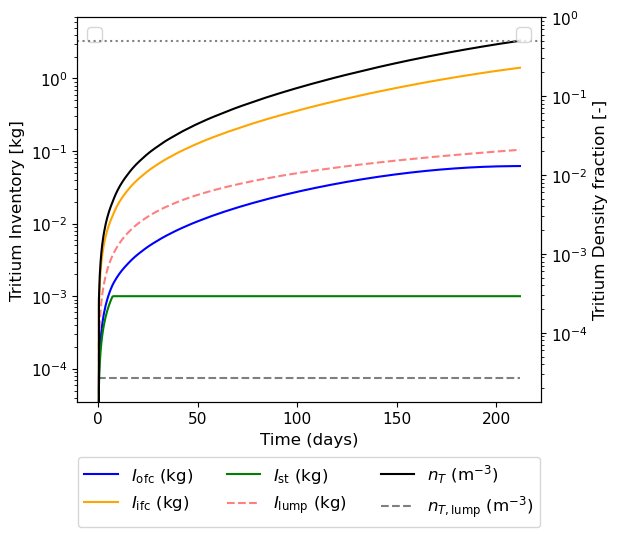

In [50]:

# plot results
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
l1, = ax1.plot(t_array/86400, N_ofc*tritium_mass, color = 'blue', linestyle = '-')
l2, = ax1.plot(t_array/86400, N_ifc*tritium_mass, color = 'orange', linestyle = '-')
l3, = ax1.plot(t_array/86400, N_st*tritium_mass, color = 'green', linestyle = '-')
l4, = ax1.plot(t_eval/86400, N_T_lump*tritium_mass, color = 'red', linestyle = '--', alpha=0.5)
l5, = ax2.plot(t_array/86400, f_T, color = 'black', linestyle = '-')
l6, = ax2.plot(t_eval/86400, f_T_lump, color = 'black', linestyle = '--', alpha=0.5)
ax1.set_xlabel('Time (days)')

# grouped legend below the figure
handles = [l1, l2, l3, l4, l5, l6]
labels = [
    r'$I_{\mathrm{ofc}}\ (\mathrm{kg})$',
    r'$I_{\mathrm{ifc}}\ (\mathrm{kg})$',
    r'$I_{\mathrm{st}}\ (\mathrm{kg})$',
    r'$I_{\mathrm{lump}}\ (\mathrm{kg})$',
    r'$n_{T}\ (\mathrm{m}^{-3})$',
    r'$n_{T,\mathrm{lump}}\ (\mathrm{m}^{-3})$'
]
# increase font sizes for legend and ticks
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.14), ncol=3, frameon=True, fontsize=12)
ax1.tick_params(axis='both', which='major', labelsize=11)
ax2.tick_params(axis='y', which='major', labelsize=11)
# enlarge axis labels
ax1.xaxis.label.set_size(12)
ax1.yaxis.label.set_size(12)
ax2.yaxis.label.set_size(12)
# make room for the legend
plt.subplots_adjust(bottom=0.30)
ax1.set_ylabel('Tritium Inventory [kg]')
ax1.set_yscale('log')
ax2.set_yscale('log')
ax2.set_ylabel('Tritium Density fraction [-]')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
ax1.set_ylim(min(N_ofc.min(), N_ifc.min(), N_st.min(), N_T_lump.min())*tritium_mass/2, max(N_ofc.max(), N_ifc.max(), N_st.max(), N_T_lump.max())*tritium_mass*5)
ax2.set_ylim(f_T_lump[-1]/2, f_T[-1]*2)
#ax1.set_yscale('log')
ax2.set_yscale('log')
# add horizontal line at n_T = 0.5 * n_tot
ax2.axhline(0.5, color='gray', linestyle=':', label='f_T = 0.5')
#ax2.set_ylim(n_tot/100, n_tot)  # Focus on relevant density range
#plt.title('Tritium Inventory and Density Evolution During Startup')

plt.tight_layout()
plt.show()


In [51]:
# ============================================================================
# VERIFICATION: Check current V_plasma and t_startup values
# ============================================================================
print("="*80)
print("CURRENT VALUES IN KERNEL")
print("="*80)
print(f"V_plasma = {V_plasma} m³")
print(f"t_startup = {t_startup:.4e} s = {t_startup/86400:.2f} days")
print()
print("Expected values:")
print("  For V_plasma = 150 m³:  t_startup ≈ 1.55e7 s ≈ 180 days")
print("  For V_plasma = 1000 m³: t_startup ≈ 2.02e7 s ≈ 234 days")
print("="*80)

CURRENT VALUES IN KERNEL
V_plasma = 150.0 m³
t_startup = 1.8301e+07 s = 211.81 days

Expected values:
  For V_plasma = 150 m³:  t_startup ≈ 1.55e7 s ≈ 180 days
  For V_plasma = 1000 m³: t_startup ≈ 2.02e7 s ≈ 234 days


## Block 2b: Calculate Time-Dependent P_aux Evolution

Now that we have the solution, we can calculate how P_aux(t) evolves throughout the startup transient.

In [52]:
# ============================================================================
# CALCULATE P_aux(t) ALONG THE SOLUTION TRAJECTORY
# ============================================================================

if sol_success:
    # Initialize arrays for P_aux components
    P_aux_array = np.zeros(len(t_array))
    
    from ddstartup.physics.power_balance import calculate_P_aux_from_power_balance
    
    # Calculate P_aux at each time point
    for i in range(len(t_array)):
        P_aux_array[i] = calculate_P_aux_from_power_balance(
            n_T[i], n_tot - n_T[i], T_i, V_plasma,
            sigmav_DD_p, sigmav_DD_n, sigmav_DT, tau_p_T
        )
    
    print("Time-Dependent P_aux Calculation Complete!")
    print(f"  P_aux at t=0: {P_aux_array[0]/1e6:.2f} MW")
    print(f"  P_aux at t=t_startup: {P_aux_array[-1]/1e6:.2f} MW")
    print(f"  P_aux range: [{P_aux_array.min()/1e6:.2f}, {P_aux_array.max()/1e6:.2f}] MW")
    print()
    
    # Check if plasma ever reaches ignition (P_aux < 0)
    if np.any(P_aux_array < 0):
        ignition_index = np.where(P_aux_array < 0)[0][0]
        t_ignition = t_array[ignition_index]
        print(f"  🔥 Plasma reaches ignition at t = {t_ignition:.2e} s = {t_ignition/86400:.2f} days")
        print(f"     n_T at ignition = {n_T[ignition_index]:.2e} m^-3 ({100*n_T[ignition_index]/n_tot:.1f}%)")
    else:
        print("  ⚠️  Plasma does not reach ignition during startup")
    print()
    
    #compare it with an equivalent reactor operating at fixed 50D-50T mixture
    n_T_eq = n_tot/2*np.ones_like(n_T)
    # Initialize arrays for P_aux components
    P_aux_array_eq = np.zeros(len(t_array))
    for i in range(len(t_array)):
        P_aux_array_eq[i] = calculate_P_aux_from_power_balance(
            n_T_eq[i], n_tot - n_T_eq[i], T_i, V_plasma,
            sigmav_DD_p, sigmav_DD_n, sigmav_DT, tau_p_T
        )
    
else:
    print("Cannot calculate P_aux evolution (infeasible solution)")
    



Time-Dependent P_aux Calculation Complete!
  P_aux at t=0: 179.10 MW
  P_aux at t=t_startup: 34.51 MW
  P_aux range: [34.51, 179.10] MW

  ⚠️  Plasma does not reach ignition during startup



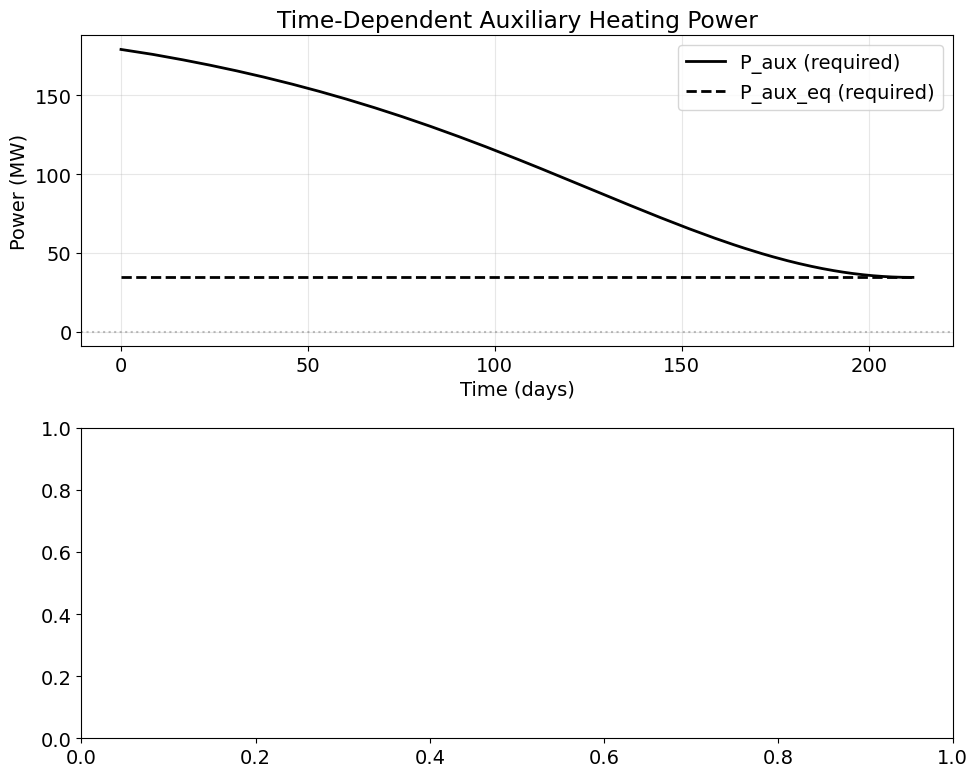

In [53]:

# Plot P_aux evolution
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Top plot: P_aux and its components
ax1.plot(t_array/86400, P_aux_array/1e6, 'k-', linewidth=2, label='P_aux (required)')
ax1.plot(t_array/86400, P_aux_array_eq/1e6, 'k--', linewidth=2, label='P_aux_eq (required)')
ax1.axhline(0, color='gray', linestyle=':', alpha=0.5)
if np.any(P_aux_array < 0):
    ax1.axvline(t_ignition/86400, color='orange', linestyle=':', label='Ignition')
ax1.set_xlabel('Time (days)')
ax1.set_ylabel('Power (MW)')
ax1.set_title('Time-Dependent Auxiliary Heating Power')
ax1.legend()
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Block 3: Calculate Power, Energy, and Unrealized Gains

Compute fusion powers, energy integrals, Q factors, and economic metrics from the ODE solution.

In [54]:
# Step 1: Calculate deuterium density evolution

if sol_success:
    n_D = n_tot - n_T
    print("Step 1: Calculate deuterium density evolution")
    print(f"  n_D = n_tot - n_T")
    print(f"  n_D ranges from {n_D[0]:.2e} to {n_D[-1]:.2e} m⁻³")
    print(f"  As tritium builds up, deuterium depletes")
    print()
else:
    n_D = np.full_like(n_T, np.nan)
    print("Step 1: Cannot compute (infeasible)")
    print()

Step 1: Calculate deuterium density evolution
  n_D = n_tot - n_T
  n_D ranges from 1.70e+20 to 8.50e+19 m⁻³
  As tritium builds up, deuterium depletes



In [55]:
# Step 2: Calculate time-dependent fusion powers

if sol_success:
    # Pre-compute common terms
    n_D_squared = n_D**2
    n_D_n_T = n_D * n_T
    V_E_DDn = V_plasma * E_DDn
    V_E_DDp = V_plasma * E_DDp
    V_E_DT = V_plasma * E_DT
    
    # Calculate fusion powers (all in Watts)
    P_DDn = n_D_squared * sigmav_DD_n / 2 * V_E_DDn
    P_DDp = n_D_squared * sigmav_DD_p / 2 * V_E_DDp
    P_DT = n_D_n_T * sigmav_DT * V_E_DT
    P_DD_tot = P_DDn + P_DDp + P_DT  # Total fusion power during startup
    
    print("Step 2: Calculate fusion powers (time-dependent)")
    print(f"  P_DDn = 0.5 * n_D² * ⟨σv⟩_DD_n * V_plasma * E_DDn")
    print(f"        ranges from {P_DDn[0]:.2e} to {P_DDn[-1]:.2e} W")
    print(f"  P_DDp = 0.5 * n_D² * ⟨σv⟩_DD_p * V_plasma * E_DDp")
    print(f"        ranges from {P_DDp[0]:.2e} to {P_DDp[-1]:.2e} W")
    print(f"  P_DT = n_D * n_T * ⟨σv⟩_DT * V_plasma * E_DT")
    print(f"       ranges from {P_DT[0]:.2e} to {P_DT[-1]:.2e} W")
    print(f"  P_DD_tot = P_DDn + P_DDp + P_DT")
    print(f"           ranges from {P_DD_tot[0]/1e6:.2f} to {P_DD_tot[-1]/1e6:.2f} MW")
    print()
else:
    P_DDn = np.full(len(n_T), np.nan)
    P_DDp = np.full(len(n_T), np.nan)
    P_DT = np.full(len(n_T), np.nan)
    P_DD_tot = np.full(len(n_T), np.nan)
    print("Step 2: Cannot compute (infeasible)")
    print()

Step 2: Calculate fusion powers (time-dependent)
  P_DDn = 0.5 * n_D² * ⟨σv⟩_DD_n * V_plasma * E_DDn
        ranges from 1.45e+06 to 3.63e+05 W
  P_DDp = 0.5 * n_D² * ⟨σv⟩_DD_p * V_plasma * E_DDp
        ranges from 1.79e+06 to 4.49e+05 W
  P_DT = n_D * n_T * ⟨σv⟩_DT * V_plasma * E_DT
       ranges from 0.00e+00 to 7.35e+08 W
  P_DD_tot = P_DDn + P_DDp + P_DT
           ranges from 3.25 to 735.91 MW



In [56]:
# Step 3: Calculate equivalent DT power (for comparison)

if sol_success:
    # This is the constant power if we had 50-50 D-T plasma from the start
    P_DT_eq = (n_tot/2)**2 * sigmav_DT * V_plasma * E_DT
    
    print("Step 3: Calculate equivalent DT power")
    print(f"  P_DT_eq = (n_tot/2)² * ⟨σv⟩_DT * V_plasma * E_DT")
    print(f"          = ({n_tot/2:.2e})² * {sigmav_DT:.2e} * {V_plasma} * {E_DT:.2e}")
    print(f"          = {P_DT_eq:.2e} W = {P_DT_eq/1e6:.2f} MW")
    print(f"  This is the constant power if we had DT from the start")
    print()
else:
    P_DT_eq = np.nan
    print("Step 3: Cannot compute (infeasible)")
    print()

Step 3: Calculate equivalent DT power
  P_DT_eq = (n_tot/2)² * ⟨σv⟩_DT * V_plasma * E_DT
          = (8.50e+19)² * 2.41e-22 * 150.0 * 2.82e-12
          = 7.35e+08 W = 735.10 MW
  This is the constant power if we had DT from the start



In [57]:
# Step 4: Integrate fusion powers over time to get total energies

if sol_success:
    # Total fusion energy produced during DD startup
    # Use interpolated time grid (t_array = t_interp) for accurate integration
    E_fusion_DDn = np.trapz(P_DDn, t_array)
    E_fusion_DDp = np.trapz(P_DDp, t_array)
    E_fusion_DT = np.trapz(P_DT, t_array)
    E_fusion_total_DD = E_fusion_DDn + E_fusion_DDp + E_fusion_DT
    E_aux_DD = np.trapz(P_aux_array, t_array)
    
    # Equivalent DT energy (constant power * time)
    E_fusion_DT_eq = P_DT_eq * t_startup
    E_aux_DT_eq = np.trapz(P_aux_array_eq, t_array)
    
    print("Step 4: Integrate fusion energies over time")
    print(f"  Using interpolated time grid for accurate integration")
    print(f"  E_fusion_DDn = ∫ P_DDn dt = {E_fusion_DDn:.2e} J = {E_fusion_DDn*joule_to_GWh:.2f} GWh")
    print(f"  E_fusion_DDp = ∫ P_DDp dt = {E_fusion_DDp:.2e} J = {E_fusion_DDp*joule_to_GWh:.2f} GWh")
    print(f"  E_fusion_DT = ∫ P_DT dt = {E_fusion_DT:.2e} J = {E_fusion_DT*joule_to_GWh:.2f} GWh")
    print(f"  E_fusion_total_DD = {E_fusion_total_DD:.2e} J = {E_fusion_total_DD*joule_to_GWh:.2f} GWh")
    print()
    print(f"  E_fusion_DT_eq = P_DT_eq * t_startup")
    print(f"                 = {P_DT_eq:.2e} * {t_startup:.2e}")
    print(f"                 = {E_fusion_DT_eq:.2e} J = {E_fusion_DT_eq*joule_to_GWh:.2f} GWh")
    print()
    print(f"  E_aux_DD = ∫ P_aux dt = {E_aux_DD:.2e} J = {E_aux_DD*joule_to_GWh:.2f} GWh")
    print(f"  E_aux_DT_eq = ∫ P_aux_eq dt = {E_aux_DT_eq:.2e} J = {E_aux_DT_eq*joule_to_GWh:.2f} GWh")
    print() 
else:
    E_fusion_DDn = np.nan
    E_fusion_DDp = np.nan
    E_fusion_DT = np.nan
    E_fusion_total_DD = np.nan
    E_fusion_DT_eq = np.nan
    print("Step 4: Cannot compute (infeasible)")
    print()


Step 4: Integrate fusion energies over time
  Using interpolated time grid for accurate integration
  E_fusion_DDn = ∫ P_DDn dt = 1.85e+13 J = 5.14 GWh
  E_fusion_DDp = ∫ P_DDp dt = 2.29e+13 J = 6.36 GWh
  E_fusion_DT = ∫ P_DT dt = 6.72e+15 J = 1867.27 GWh
  E_fusion_total_DD = 6.76e+15 J = 1878.78 GWh

  E_fusion_DT_eq = P_DT_eq * t_startup
                 = 7.35e+08 * 1.83e+07
                 = 1.35e+16 J = 3736.93 GWh

  E_aux_DD = ∫ P_aux dt = 1.95e+15 J = 542.40 GWh
  E_aux_DT_eq = ∫ P_aux_eq dt = 6.32e+14 J = 175.46 GWh



/tmp/ipykernel_75740/7548282.py:6: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  E_fusion_DDn = np.trapz(P_DDn, t_array)
/tmp/ipykernel_75740/7548282.py:7: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  E_fusion_DDp = np.trapz(P_DDp, t_array)
/tmp/ipykernel_75740/7548282.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  E_fusion_DT = np.trapz(P_DT, t_array)
/tmp/ipykernel_75740/7548282.py:10: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  E_aux_DD = np.trapz(P_aux_array, t_array)
/tmp/ipykernel_75740/7548282.py:14: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functio

In [58]:
# Step 6: Calculate net electrical energies

if sol_success:
    E_e_net_DD = capacity_factor * (eta_th * E_fusion_total_DD - E_aux_DD)
    E_e_net_DT_eq = capacity_factor * (eta_th * E_fusion_DT_eq - E_aux_DT_eq)
    
    print("Step 6: Calculate net electrical energies")
    print(f"  E_e_net_DD = capacity_factor * (η_th * E_fusion_total_DD - E_aux_DD)")
    print(f"             = {capacity_factor} * ({eta_th} * {E_fusion_total_DD:.2e} - {E_aux_DD:.2e})")
    print(f"             = {E_e_net_DD:.2e} J = {E_e_net_DD*joule_to_GWh:.2f} GWh")
    if E_e_net_DD > 0:
        print(f"  ✓ Net electricity production during DD startup")
    else:
        print(f"  ✗ Net electricity consumption during DD startup")
    print()
    print(f"  E_e_net_DT_eq = capacity_factor * (η_th * E_fusion_DT_eq - E_aux_DT_eq)")
    print(f"                = {capacity_factor} * ({eta_th} * {E_fusion_DT_eq:.2e} - {E_aux_DT_eq:.2e})")
    print(f"                = {E_e_net_DT_eq:.2e} J = {E_e_net_DT_eq*joule_to_GWh:.2f} GWh")
    print()
else:
    E_e_net_DD = np.nan
    E_e_net_DT_eq = np.nan
    print("Step 6: Cannot compute (infeasible)")
    print()

Step 6: Calculate net electrical energies
  E_e_net_DD = capacity_factor * (η_th * E_fusion_total_DD - E_aux_DD)
             = 0.8 * (0.4 * 6.76e+15 - 1.95e+15)
             = 6.02e+14 J = 167.28 GWh
  ✓ Net electricity production during DD startup

  E_e_net_DT_eq = capacity_factor * (η_th * E_fusion_DT_eq - E_aux_DT_eq)
                = 0.8 * (0.4 * 1.35e+16 - 6.32e+14)
                = 3.80e+15 J = 1055.45 GWh



In [59]:
# Step 7: Calculate Q factors

if sol_success:
    Q_DD = E_fusion_total_DD / E_aux_DD if E_aux_DD > 0 else np.inf
    Q_DT_eq = E_fusion_DT_eq / E_aux_DT_eq if E_aux_DT_eq > 0 else np.inf
    
    print("Step 7: Calculate Q factors (energy-based)")
    print(f"  Q_DD = E_fusion_total_DD / E_aux_DD")
    print(f"       = {E_fusion_total_DD:.2e} / {E_aux_DD:.2e}")
    print(f"       = {Q_DD:.4f}")
    if Q_DD > 1:
        print(f"  ✓ Net energy gain during DD startup (Q > 1)")
    else:
        print(f"  ✗ Net energy loss during DD startup (Q < 1)")
    print()
    print(f"  Q_DT_eq = E_fusion_DT_eq / E_aux_DT_eq")
    print(f"          = {E_fusion_DT_eq:.2e} / {E_aux_DT_eq:.2e}")
    print(f"          = {Q_DT_eq:.4f}")
    print()
else:
    Q_DD = np.nan
    Q_DT_eq = np.nan
    print("Step 7: Cannot compute (infeasible)")
    print()

Step 7: Calculate Q factors (energy-based)
  Q_DD = E_fusion_total_DD / E_aux_DD
       = 6.76e+15 / 1.95e+15
       = 3.4638
  ✓ Net energy gain during DD startup (Q > 1)

  Q_DT_eq = E_fusion_DT_eq / E_aux_DT_eq
          = 1.35e+16 / 6.32e+14
          = 21.2981



In [60]:
# Step 8: Calculate LOST ENERGY and UNREALIZED GAINS

if sol_success:
    E_lost = E_e_net_DT_eq - E_e_net_DD
    unrealized_profits = E_lost * price_of_electricity
    
    print("Step 8: Calculate lost energy and unrealized gains")
    print(f"  E_lost = E_e_net_DT_eq - E_e_net_DD")
    print(f"         = {E_e_net_DT_eq:.2e} - {E_e_net_DD:.2e}")
    print(f"         = {E_lost:.2e} J = {E_lost*joule_to_GWh:.2f} GWh")
    if E_lost > 0:
        print(f"  ⚠️  Lost energy: DT would have produced MORE")
    else:
        print(f"  ✓ No lost energy: DD produced as much or more than DT")
    print()
    print(f"  💰 Unrealized gains = E_lost * price_of_electricity")
    print(f"                      = {E_lost:.2e} * {price_of_electricity:.2e}")
    print(f"                      = ${unrealized_profits:.2e}")
    print(f"                      = {unrealized_profits/1e6:.2f} M$")
    print(f"\n  This is the financial penalty of DD startup vs. having tritium from day 1")
    print()
else:
    E_lost = np.nan
    unrealized_profits = np.nan
    print("Step 8: Cannot compute (infeasible)")
    print()

Step 8: Calculate lost energy and unrealized gains
  E_lost = E_e_net_DT_eq - E_e_net_DD
         = 3.80e+15 - 6.02e+14
         = 3.20e+15 J = 888.17 GWh
  ⚠️  Lost energy: DT would have produced MORE

  💰 Unrealized gains = E_lost * price_of_electricity
                      = 3.20e+15 * 6.94e-08
                      = $2.22e+08
                      = 222.04 M$

  This is the financial penalty of DD startup vs. having tritium from day 1



Lost fusion energy at the end of the transient: 1854.3859654920557 GWh
Lost electric energy at the end of the transient: 887.831324156869 GWh


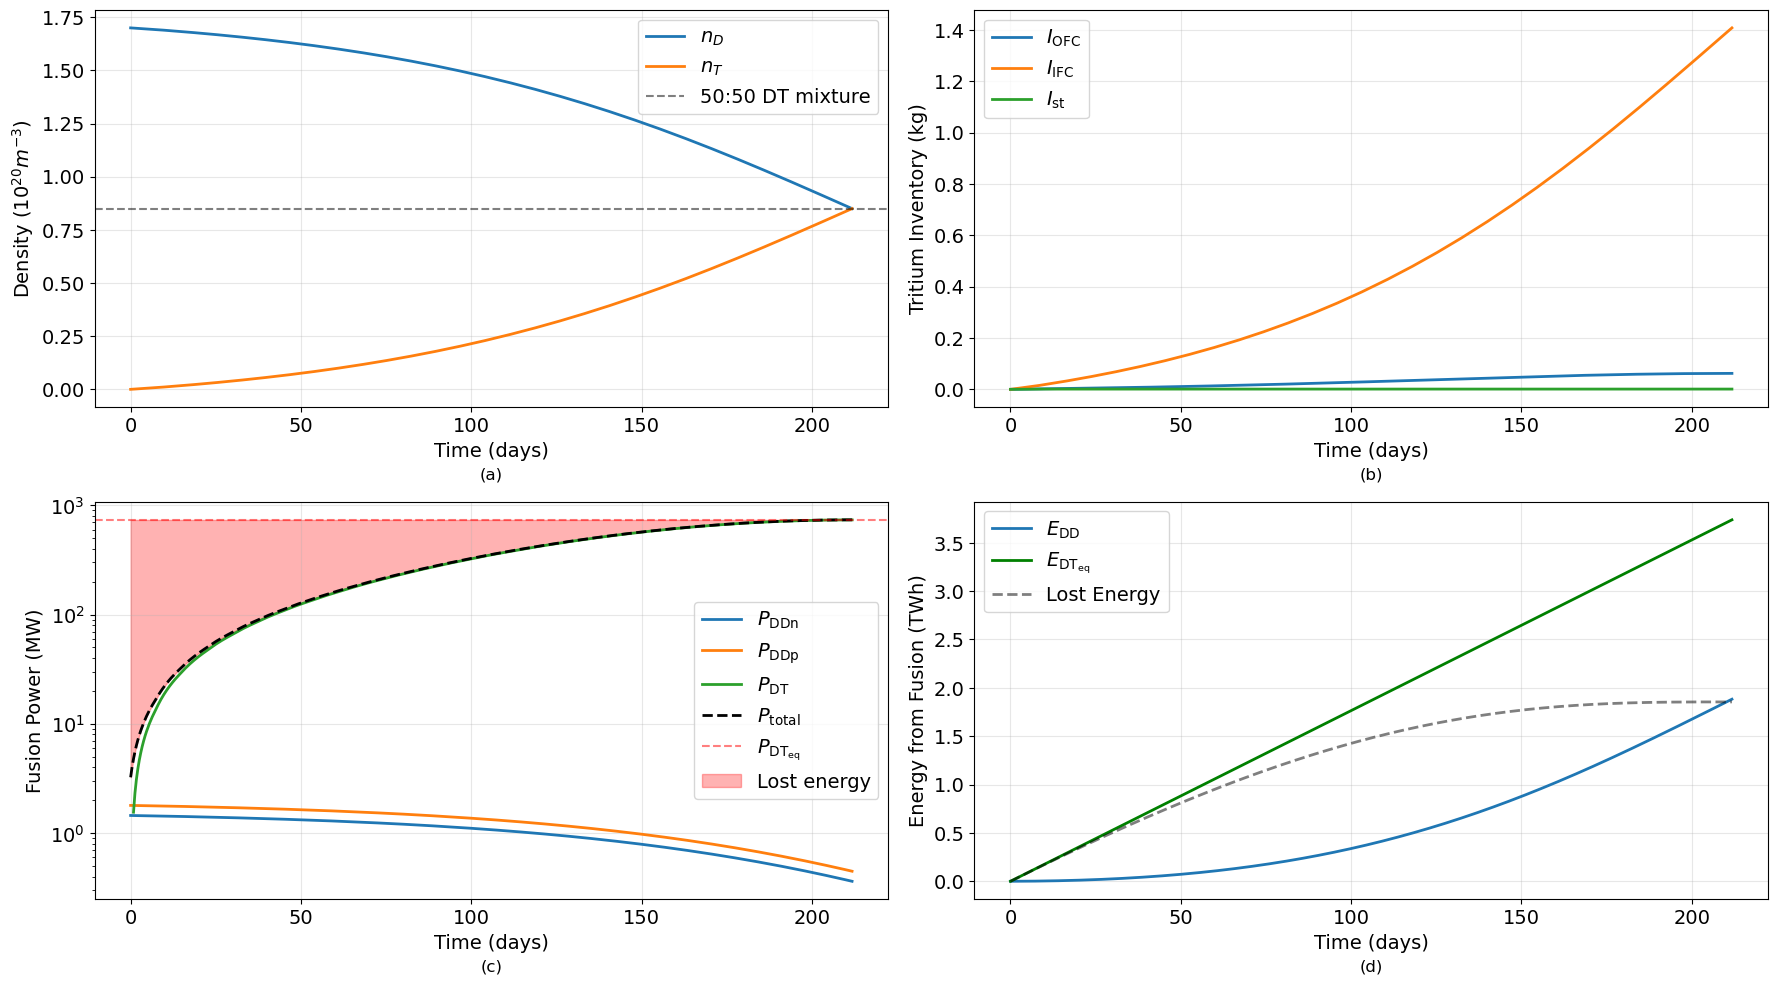

<Figure size 640x480 with 0 Axes>

✅ Plots generated successfully!


In [61]:
plt.rcParams.update({'font.size': 14})

if sol_success:
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 10))
    
    # Plot 1: Plasma composition
    ax1 = axes[0, 0]
    ax1.plot(t_array/86400, n_D/1e20, label=r'$n_D$', linewidth=2)
    ax1.plot(t_array/86400, n_T/1e20, label=r'$n_T$', linewidth=2)
    ax1.axhline(y=0.5*n_tot/1e20, color='k', linestyle='--', alpha=0.5, label=r'50:50 DT mixture')
    ax1.set_xlabel('Time (days)')
    ax1.set_ylabel(r'Density ($10^{20} m^{-3}$)')
    ax1.legend(loc = 'upper right')
    ax1.grid(True, alpha=0.3)
    ax1.text(0.5, -0.15, '(a)', transform=ax1.transAxes, fontsize=12, va='top', ha='center')

    # Plot 2: Tritium inventory
    ax2 = axes[0, 1]
    ax2.plot(t_array/86400, N_ofc*tritium_mass, label=r'$I_\mathrm{OFC}$', linewidth=2)
    ax2.plot(t_array/86400, N_ifc*tritium_mass, label=r'$I_\mathrm{IFC}$', linewidth=2)
    ax2.plot(t_array/86400, N_st*tritium_mass, label=r'$I_\mathrm{st}$', linewidth=2)
    ax2.set_xlabel('Time (days)')
    ax2.set_ylabel('Tritium Inventory (kg)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.text(0.5, -0.15, '(b)', transform=ax2.transAxes, fontsize=12, va='top', ha='center')
 
    # Plot 3: Fusion powers
    ax3 = axes[1, 0]
    mask = P_DT >= P_DDn 
    ax3.plot(t_array/86400, P_DDn/1e6, label=r'$P_\mathrm{DDn}$', linewidth=2)
    ax3.plot(t_array/86400, P_DDp/1e6, label=r'$P_\mathrm{DDp}$', linewidth=2)
    ax3.plot(t_array[mask]/86400, P_DT[mask]/1e6, label=r'$P_\mathrm{DT}$', linewidth=2)
    ax3.plot(t_array/86400, P_DD_tot/1e6, label=r'$P_\mathrm{total}$', linewidth=2, linestyle='--', color='black')
    ax3.axhline(y=P_DT_eq/1e6, color='r', linestyle='--', alpha=0.5, label=r'$P_\mathrm{DT_{eq}}$')
    
    # Fill the area between P_DD_tot and P_DT_eq
    ax3.fill_between(t_array/86400, P_DD_tot/1e6, P_DT_eq/1e6, where=(P_DD_tot/1e6 < P_DT_eq/1e6), color='red', alpha=0.3, label='Lost energy')
    
    ax3.set_xlabel('Time (days)')
    ax3.set_ylabel('Fusion Power (MW)')
    ax3.set_yscale('log')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    ax3.text(0.5, -0.15, '(c)', transform=ax3.transAxes, fontsize=12, va='top', ha='center')
    # Plot 4: Cumulative energy
    
    cumulative_E_DD_electric = np.cumsum(capacity_factor*(eta_th*P_DD_tot-P_aux_array)*np.ones_like(t_array) * np.gradient(t_array)) * joule_to_GWh # from J to GWh
    cumulative_E_DT_eq_electric = np.ones_like(t_array)*capacity_factor*(eta_th*P_DT_eq-P_aux_array_eq) * t_array*joule_to_GWh # from J to GWh
    
    cumulative_E_DD_fusion = np.cumsum(P_DD_tot*np.ones_like(t_array) * np.gradient(t_array)) * joule_to_GWh # from J to GWh
    cumulative_E_DT_eq_fusion = np.ones_like(t_array)*P_DT_eq * t_array*joule_to_GWh # from J to GWh
    
    ax4 = axes[1, 1]
    #ax4.plot(t_array/86400, cumulative_E_DD_electric/1e3, label=r'$E_\mathrm{DD}$', linewidth=2)
    #ax4.plot(t_array/86400, cumulative_E_DT_eq_electric/1e3, label=r'$E_\mathrm{DT_{eq}}$', linewidth=2, color='green')
    #ax4.plot(t_array/86400, (cumulative_E_DT_eq_electric - cumulative_E_DD_electric)/1e3, linewidth=2, linestyle='--', color='black', label='Lost Energy')
    ax4.plot(t_array/86400, cumulative_E_DD_fusion/1e3, label=r'$E_\mathrm{DD}$', linewidth=2)
    ax4.plot(t_array/86400, cumulative_E_DT_eq_fusion/1e3, label=r'$E_\mathrm{DT_{eq}}$', linewidth=2, color='green')
    ax4.plot(t_array/86400, (cumulative_E_DT_eq_fusion - cumulative_E_DD_fusion)/1e3, linewidth=2, linestyle='--', color='black', alpha=0.5, label='Lost Energy')
    
    
    ax4.set_xlabel('Time (days)')
    ax4.set_ylabel('Energy from Fusion (TWh)')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    ax4.text(0.5, -0.15, '(d)', transform=ax4.transAxes, fontsize=12, va='top', ha='center')
    print(f'Lost fusion energy at the end of the transient: {cumulative_E_DT_eq_fusion[-1] - cumulative_E_DD_fusion[-1]} GWh')
    print(f'Lost electric energy at the end of the transient: {cumulative_E_DT_eq_electric[-1] - cumulative_E_DD_electric[-1]} GWh')
    plt.tight_layout()
    plt.savefig('T_seeded_point_design.pdf', dpi=300)
    plt.show()
    
    # # Plot 4: Cumulative energy
    # cumulative_E_DD_electric = np.cumsum(capacity_factor*(eta_th*P_DD_tot-P_aux_array)*np.ones_like(t_array) * np.gradient(t_array)) * joule_to_GWh # from J to GWh
    # cumulative_E_DT_eq_electric = np.ones_like(t_array)*capacity_factor*(eta_th*P_DT_eq-P_aux_array_eq) * t_array*joule_to_GWh # from J to GWh
    
    # ax4 = axes[1, 1]
    # ax4.plot(t_array/86400, cumulative_E_DD_electric, label=r'$E_\mathrm{DD}$', linewidth=2)
    # ax4.plot(t_array/86400, cumulative_E_DT_eq_electric, label=r'$E_\mathrm{DT_{eq}}$', linewidth=2, color='green')
    # ax4.plot(t_array/86400, (cumulative_E_DT_eq_electric - cumulative_E_DD_electric), linewidth=2, linestyle='--', color='black', alpha=0.5, label='Lost Energy')
    # ax4.set_xlabel('Time (days)')
    # ax4.set_ylabel('Energy (GWh)')
    # ax4.legend(fontsize=10)
    # ax4.grid(True, alpha=0.3)
    # ax4.text(0.5, -0.15, '(d)', transform=ax4.transAxes, fontsize=12, va='top', ha='center')
    # print(f'Lost energy at the end of the transient (realistic P_aux): {cumulative_E_DT_eq_electric[-1] - cumulative_E_DD_electric[-1]} GWh')
    # # print(f'Lost energy at the end of the transient (fixed P_aux): {cumulative_E_DT_eq_electric[-1] - cumulative_E_DD_electric_fixed[-1]} GWh')
    
    
    plt.tight_layout()
    plt.savefig('T_seeded_point_design.pdf', dpi=300)
    plt.show()
    
    print("✅ Plots generated successfully!")
else:
    print("❌ Cannot plot: solution not successful")



Lost fusion energy at the end of the transient: 1854.3859654920557 GWh
Lost electric energy at the end of the transient: 887.831324156869 GWh


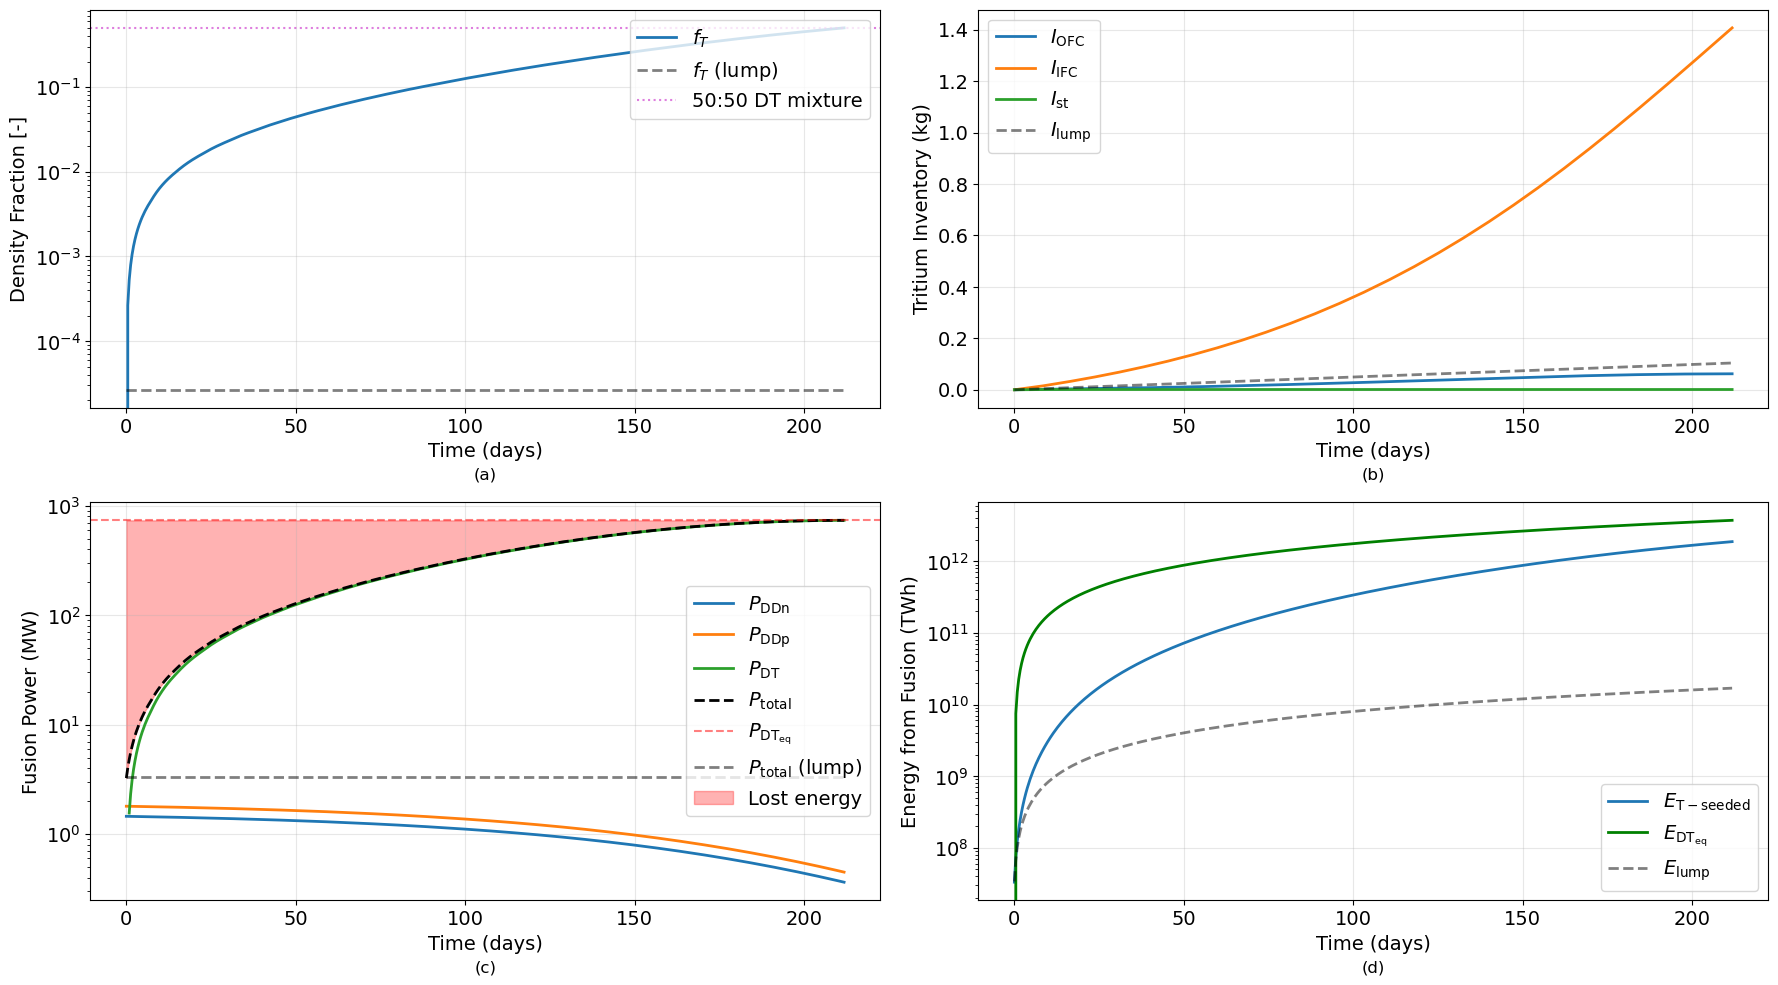

<Figure size 640x480 with 0 Axes>

✅ Plots generated successfully!


In [62]:
plt.rcParams.update({'font.size': 14})

if sol_success:
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 10))

    # Plot 1: Plasma composition
    ax1 = axes[0, 0]
    # ax1.plot(t_array/86400, n_D/n_tot, label=r'$f_D$', linewidth=2)
    ax1.plot(t_array/86400, n_T/n_tot, label=r'$f_T$', linewidth=2)
    # also plot the evolution of the lump equivalent model
    ax1.plot(t_array/86400, n_T_lump/n_tot, label=r'$f_T$ (lump)', linewidth=2, color = 'black', linestyle='--', alpha=0.5)
    ax1.axhline(y=0.5, color='m', linestyle=':', alpha=0.5, label=r'50:50 DT mixture')
    ax1.set_xlabel('Time (days)')
    ax1.set_ylabel(r'Density Fraction [-]')
    ax1.legend(loc = 'upper right')
    ax1.grid(True, alpha=0.3)
    ax1.set_yscale('log')
    ax1.text(0.5, -0.15, '(a)', transform=ax1.transAxes, fontsize=12, va='top', ha='center')

    # Plot 2: Tritium inventory
    ax2 = axes[0, 1]
    ax2.plot(t_array/86400, N_ofc*tritium_mass, label=r'$I_\mathrm{OFC}$', linewidth=2)
    ax2.plot(t_array/86400, N_ifc*tritium_mass, label=r'$I_\mathrm{IFC}$', linewidth=2)
    ax2.plot(t_array/86400, N_st*tritium_mass, label=r'$I_\mathrm{st}$', linewidth=2)
    ax2.plot(t_array/86400, N_T_lump*tritium_mass, label=r'$I_\mathrm{lump}$', linewidth=2, color = 'black', linestyle='--', alpha=0.5)
    ax2.set_xlabel('Time (days)')
    ax2.set_ylabel('Tritium Inventory (kg)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.text(0.5, -0.15, '(b)', transform=ax2.transAxes, fontsize=12, va='top', ha='center')
 
 
 
 
    # Plot 3: Fusion powers
    ax3 = axes[1, 0]
    mask = P_DT >= P_DDn 
    ax3.plot(t_array/86400, P_DDn/1e6, label=r'$P_\mathrm{DDn}$', linewidth=2)
    ax3.plot(t_array/86400, P_DDp/1e6, label=r'$P_\mathrm{DDp}$', linewidth=2)
    ax3.plot(t_array[mask]/86400, P_DT[mask]/1e6, label=r'$P_\mathrm{DT}$', linewidth=2)
    ax3.plot(t_array/86400, P_DD_tot/1e6, label=r'$P_\mathrm{total}$', linewidth=2, linestyle='--', color='black')
    ax3.axhline(y=P_DT_eq/1e6, color='r', linestyle='--', alpha=0.5, label=r'$P_\mathrm{DT_{eq}}$')
    ax3.plot(t_array/86400, P_F_lump/1e6, label=r'$P_\mathrm{total}$ (lump)', linewidth=2, color = 'black', linestyle='--', alpha=0.5)
    # Fill the area between P_DD_tot and P_DT_eq
    ax3.fill_between(t_array/86400, P_DD_tot/1e6, P_DT_eq/1e6, where=(P_DD_tot/1e6 < P_DT_eq/1e6), color='red', alpha=0.3, label='Lost energy')
    
    ax3.set_xlabel('Time (days)')
    ax3.set_ylabel('Fusion Power (MW)')
    ax3.set_yscale('log')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    ax3.text(0.5, -0.15, '(c)', transform=ax3.transAxes, fontsize=12, va='top', ha='center')
    # Plot 4: Cumulative energy
    
    cumulative_E_DD_electric = np.cumsum(capacity_factor*(eta_th*P_DD_tot-P_aux_array)*np.ones_like(t_array) * np.gradient(t_array)) * joule_to_GWh # from J to GWh
    cumulative_E_DT_eq_electric = np.ones_like(t_array)*capacity_factor*(eta_th*P_DT_eq-P_aux_array_eq) * t_array*joule_to_GWh # from J to GWh
    
    cumulative_E_DD_fusion = np.cumsum(P_DD_tot*np.ones_like(t_array) * np.gradient(t_array)) * joule_to_GWh # from J to GWh
    cumulative_E_DT_eq_fusion = np.ones_like(t_array)*P_DT_eq * t_array*joule_to_GWh # from J to GWh
    cumulative_E_lump_fusion = np.cumsum(P_F_lump*np.ones_like(t_array) * np.gradient(t_array)) * joule_to_GWh # from J to GWh
    ax4 = axes[1, 1]
    #ax4.plot(t_array/86400, cumulative_E_DD_electric/1e3, label=r'$E_\mathrm{DD}$', linewidth=2)
    #ax4.plot(t_array/86400, cumulative_E_DT_eq_electric/1e3, label=r'$E_\mathrm{DT_{eq}}$', linewidth=2, color='green')
    #ax4.plot(t_array/86400, (cumulative_E_DT_eq_electric - cumulative_E_DD_electric)/1e3, linewidth=2, linestyle='--', color='black', label='Lost Energy')
    ax4.plot(t_array/86400, cumulative_E_DD_fusion*1e9, label=r'$E_\mathrm{T-seeded}$', linewidth=2)
    ax4.plot(t_array/86400, cumulative_E_DT_eq_fusion*1e9, label=r'$E_\mathrm{DT_{eq}}$', linewidth=2, color='green')
    ax4.plot(t_array/86400, cumulative_E_lump_fusion*1e9, label=r'$E_\mathrm{lump}$', linewidth=2, color='black', linestyle='--', alpha=0.5)
    #ax4.plot(t_array/86400, (cumulative_E_DT_eq_fusion - cumulative_E_DD_fusion)*1e9, linewidth=2, linestyle='--', color='red', alpha=0.5, label='Lost Energy')
    
    
    ax4.set_xlabel('Time (days)')
    ax4.set_ylabel('Energy from Fusion (TWh)')
    ax4.legend()
    ax4.set_yscale('log')
    ax4.grid(True, alpha=0.3)
    ax4.text(0.5, -0.15, '(d)', transform=ax4.transAxes, fontsize=12, va='top', ha='center')
    print(f'Lost fusion energy at the end of the transient: {cumulative_E_DT_eq_fusion[-1] - cumulative_E_DD_fusion[-1]} GWh')
    print(f'Lost electric energy at the end of the transient: {cumulative_E_DT_eq_electric[-1] - cumulative_E_DD_electric[-1]} GWh')
    plt.tight_layout()
    plt.savefig('T_seeded_point_design.pdf', dpi=300)
    plt.show()
    
    # # Plot 4: Cumulative energy
    # cumulative_E_DD_electric = np.cumsum(capacity_factor*(eta_th*P_DD_tot-P_aux_array)*np.ones_like(t_array) * np.gradient(t_array)) * joule_to_GWh # from J to GWh
    # cumulative_E_DT_eq_electric = np.ones_like(t_array)*capacity_factor*(eta_th*P_DT_eq-P_aux_array_eq) * t_array*joule_to_GWh # from J to GWh
    
    # ax4 = axes[1, 1]
    # ax4.plot(t_array/86400, cumulative_E_DD_electric, label=r'$E_\mathrm{DD}$', linewidth=2)
    # ax4.plot(t_array/86400, cumulative_E_DT_eq_electric, label=r'$E_\mathrm{DT_{eq}}$', linewidth=2, color='green')
    # ax4.plot(t_array/86400, (cumulative_E_DT_eq_electric - cumulative_E_DD_electric), linewidth=2, linestyle='--', color='black', alpha=0.5, label='Lost Energy')
    # ax4.set_xlabel('Time (days)')
    # ax4.set_ylabel('Energy (GWh)')
    # ax4.legend(fontsize=10)
    # ax4.grid(True, alpha=0.3)
    # ax4.text(0.5, -0.15, '(d)', transform=ax4.transAxes, fontsize=12, va='top', ha='center')
    # print(f'Lost energy at the end of the transient (realistic P_aux): {cumulative_E_DT_eq_electric[-1] - cumulative_E_DD_electric[-1]} GWh')
    # # print(f'Lost energy at the end of the transient (fixed P_aux): {cumulative_E_DT_eq_electric[-1] - cumulative_E_DD_electric_fixed[-1]} GWh')
    
    
    plt.tight_layout()
    plt.savefig('T_seeded_point_design.pdf', dpi=300)
    plt.show()
    
    print("✅ Plots generated successfully!")
else:
    print("❌ Cannot plot: solution not successful")



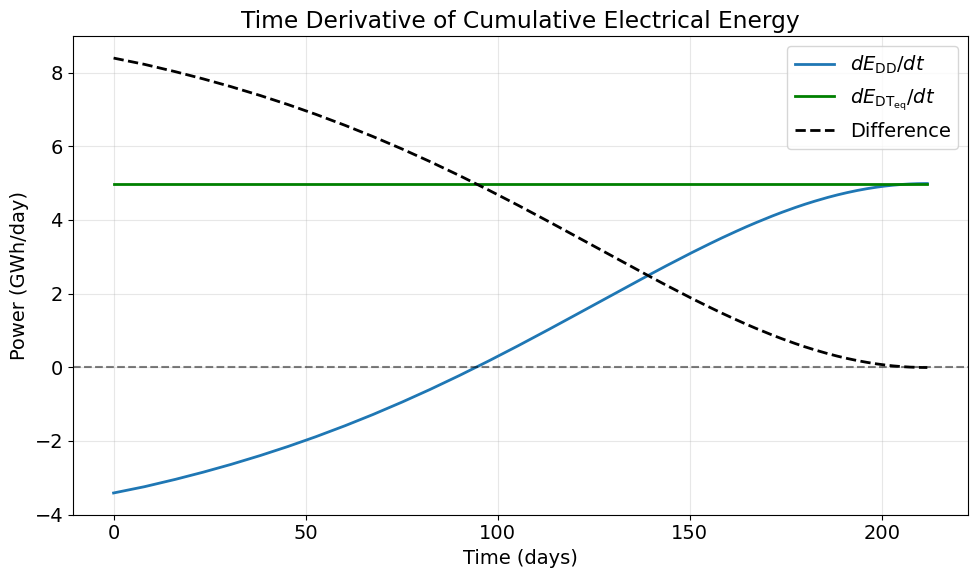

✅ Power balance plot generated successfully!


In [63]:
# plot the evolution of the derivatives of cumulative energies to show power balance
if sol_success:
    import matplotlib.pyplot as plt
    
    dE_DD_electric_dt = capacity_factor*(eta_th*P_DD_tot - P_aux_array) * joule_to_GWh  # in GWh/s
    dE_DT_eq_electric_dt = capacity_factor*(eta_th*P_DT_eq - P_aux_array_eq) * joule_to_GWh  # in GWh/s
    dE_difference_dt = dE_DT_eq_electric_dt - dE_DD_electric_dt  # in GWh/s
    plt.figure(figsize=(10,6))
    plt.plot(t_array/86400, dE_DD_electric_dt*86400, label=r'$dE_\mathrm{DD}/dt$', linewidth=2)
    plt.plot(t_array/86400, dE_DT_eq_electric_dt*86400, label=r'$dE_\mathrm{DT_{eq}}/dt$', linewidth=2, color='green')
    plt.plot(t_array/86400, dE_difference_dt*86400, label='Difference', linewidth=2, linestyle='--', color='black')
    plt.axhline(0, color='black', linestyle='--', alpha=0.5)
    plt.xlabel('Time (days)')
    plt.ylabel('Power (GWh/day)')
    plt.title('Time Derivative of Cumulative Electrical Energy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("✅ Power balance plot generated successfully!")    # Create a new uniform time grid from 0 to t_startup
    vector_length = 1000  # Number of points in the uniform grid
    t_interp = np.linspace(0, t_startup, vector_length)

In [74]:
# compute the cost per W of the plant
K_el = unrealized_profits / (capacity_factor*(eta_th*P_DT_eq - P_aux_array_eq[-1]))
K_fus = unrealized_profits / (P_DT_eq)
print(f"K = {K_fus} $/W considering fusion power\n"
      f"K = {K_el} $/W considering electric power ")

K = 0.3020549638796844 $/W considering fusion power
K = 1.0694558474618439 $/W considering electric power 
